In [10]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms, datasets
from torchinfo import summary
from torch.utils.data import DataLoader, Subset

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [3]:
device

'mps'

In [4]:
IMG_SIZE = 224
seed = 42

In [5]:
def to_rgb(img):
    return img.convert("RGB")

In [8]:
train_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.RandomResizedCrop(IMG_SIZE, scale = (0.6,1), ratio = (0.75,1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue = 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), #imagenet standard values
    #transforms.RandomErasing(p=0.25, scale = (0.02, 0.15), ratio =(0.3, 3.3), value = "random")
])

In [9]:
test_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [11]:
from torch.utils.data import random_split
root = "../data"
test_ratio = 0.2



In [12]:
ds_train_full = datasets.Caltech101(root =root, download = True, transform = train_tf) 
ds_test_full = datasets.Caltech101(root =root, download = True, transform = test_tf) 

100%|████████████████████████████████████████| 137M/137M [00:08<00:00, 16.1MB/s]


In [13]:
n_total = len(ds_train_full)

In [14]:
n_total

8677

In [15]:
n_test = int(n_total * test_ratio)

In [16]:
n_total, n_test

(8677, 1735)

In [17]:
n_train = n_total - n_test

In [18]:
n_total, n_test, n_train

(8677, 1735, 6942)

In [19]:
g = torch.Generator().manual_seed(seed)
perm = torch.randperm(n_total,generator = g).tolist()

In [21]:
train_idx = perm[:n_train]
test_idx = perm[n_train:]

In [22]:
len(train_idx), len(test_idx)

(6942, 1735)

In [23]:
train_ds = Subset(ds_train_full, train_idx)
test_ds = Subset(ds_test_full, test_idx)

In [24]:
len(train_ds), len(test_ds)

(6942, 1735)

In [25]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle=False)

In [31]:
img, label = ds_train_full[1000]

In [32]:
print(label)
print(ds_train_full.categories[label])

2
Leopards


In [35]:
height = 224
width = 224
color_channels = 3
patch_size = 16

number_of_patches = int((height * width) / (patch_size ** 2))

In [36]:
number_of_patches

196

In [39]:
embedding_layer_input_shape = (height, width, color_channels)
embedding_layer_output_shape = (number_of_patches, patch_size ** 2 * color_channels)

In [40]:
print(embedding_layer_input_shape)
print(embedding_layer_output_shape)

(224, 224, 3)
(196, 768)


In [41]:
224*224*3

150528

In [42]:
196*768

150528

In [43]:
image, label = train_dataloader.dataset[4]

In [45]:
class_names = ds_train_full.categories

In [46]:
class_names[label]

'helicopter'

In [47]:
image

tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., -1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2914162].


Text(0.5, 1.0, 'helicopter')

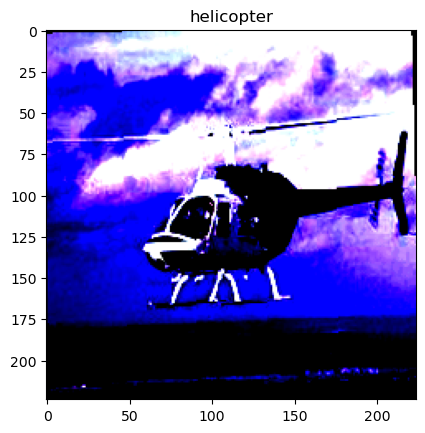

In [49]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.169412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2042704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2391288].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2565577].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2391288].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2565577].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8960528..2.256

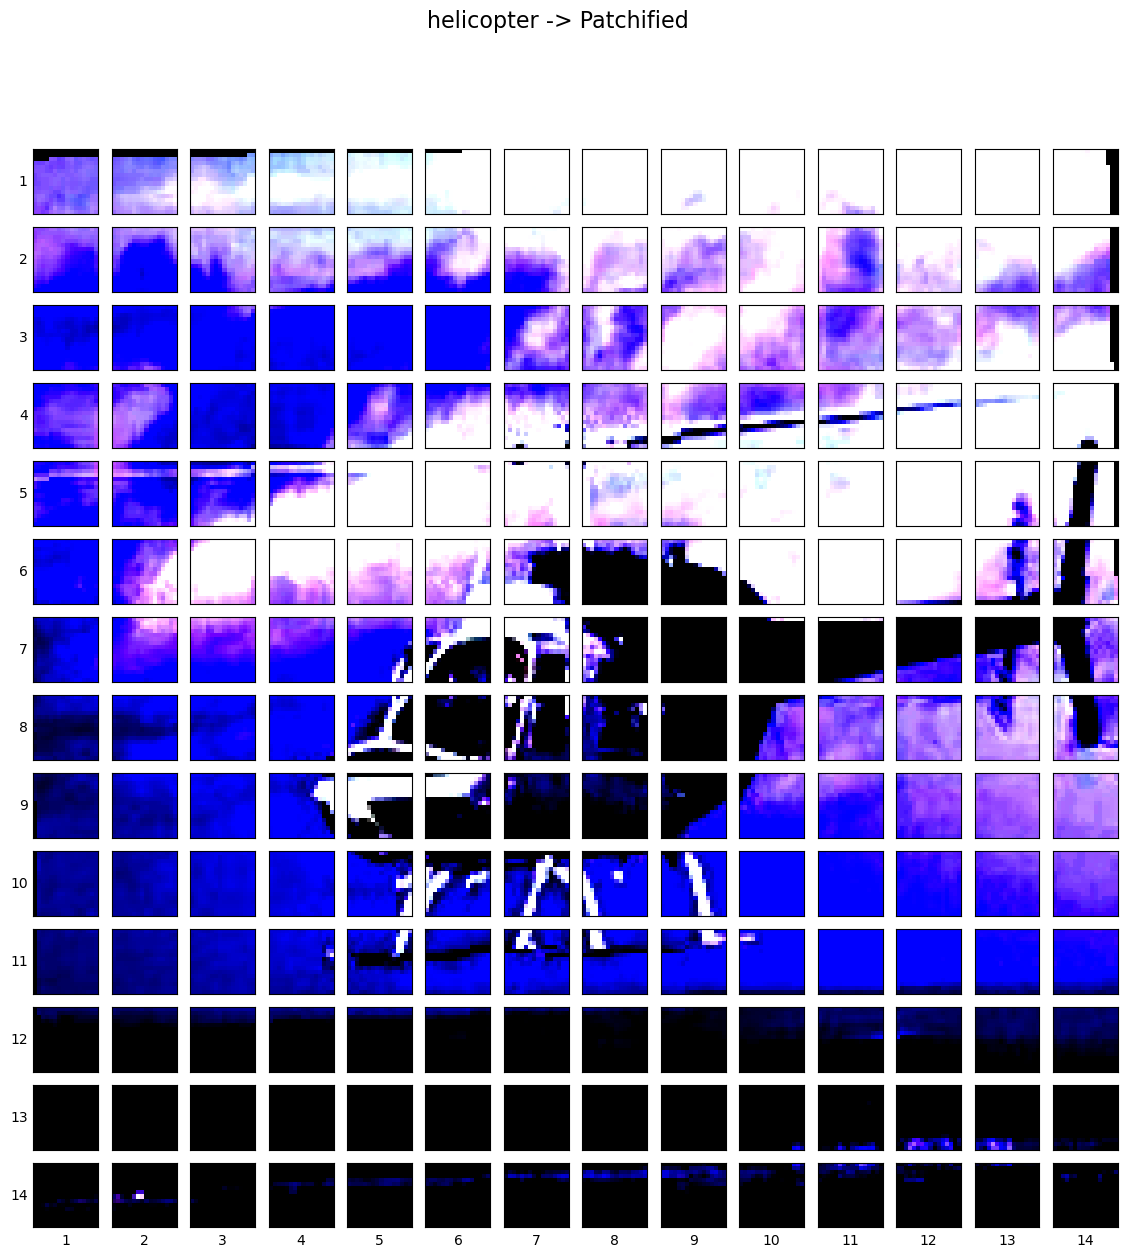

In [50]:
image_permuted = image.permute(1, 2, 0)
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

In [52]:
patch_size = 16
conv2d = nn.Conv2d(in_channels=3,
                  out_channels = 768,
                  kernel_size = patch_size,
                  stride = patch_size,
                  padding = 0)

In [53]:
image_out_of_conv = conv2d(image)

In [55]:
image_out_of_conv.shape

torch.Size([768, 14, 14])

In [56]:
flatten = nn.Flatten(start_dim=1, end_dim=2)

In [57]:
image_out_of_conv_flattened = flatten(image_out_of_conv)

In [58]:
image_out_of_conv_flattened.shape

torch.Size([768, 196])

In [59]:
image_out_of_conv = conv2d(image.unsqueeze(0))

In [60]:
image_out_of_conv.shape

torch.Size([1, 768, 14, 14])

In [61]:
flatten = nn.Flatten(start_dim=2, end_dim=3)

In [62]:
image_out_of_conv_flattened = flatten(image_out_of_conv)

In [63]:
image_out_of_conv_flattened.shape

torch.Size([1, 768, 196])

In [68]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels: int = 3, embedding_dim: int = 768, patch_size: int = 16, start_dim:int = 2, end_dim:int = 3):
        super().__init__()

        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding = 0)
        self.flatten = nn.Flatten(start_dim = start_dim, end_dim = end_dim)

    def forward(self, x):
        x = self.patcher(x)
        x = self.flatten(x)

        return x.permute(0,2,1)

In [69]:
patch_embedding = PatchEmbedding()

In [70]:
patch_embedded_image = patch_embedding(image.unsqueeze(0))

In [71]:
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [72]:
random_input_image = (1,3,224,224)

summary(PatchEmbedding(),
        input_size=random_input_image,
        col_names =["input_size",
                "output_size",
                "num_params",
                "trainable",])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
PatchEmbedding                           [1, 3, 224, 224]          [1, 196, 768]             --                        True
├─Conv2d: 1-1                            [1, 3, 224, 224]          [1, 768, 14, 14]          590,592                   True
├─Flatten: 1-2                           [1, 768, 14, 14]          [1, 768, 196]             --                        --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [73]:
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [74]:
batch_size = patch_embedded_image.shape[0]

In [76]:
embedding_dimension = patch_embedded_image.shape[-1]

In [77]:
class_token = nn.Parameter(torch.ones(batch_size,1,embedding_dimension), requires_grad=True)

In [78]:
class_token.shape

torch.Size([1, 1, 768])

In [80]:
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image), dim=1)

In [81]:
patch_embedded_image_with_class_embedding

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [ 0.8869,  1.0128,  0.7900,  ..., -0.6917, -0.4512, -0.3582],
         [ 0.5631,  0.7112,  1.1136,  ..., -0.4669, -0.3551, -0.1849],
         ...,
         [-0.7254, -0.0520, -0.5542,  ...,  0.4475, -0.7773, -0.4010],
         [-0.9558,  0.1566, -0.8571,  ...,  0.9211, -0.6116, -0.4728],
         [-0.5318,  0.1637, -0.6943,  ...,  0.7665, -0.7989, -0.4846]]],
       grad_fn=<CatBackward0>)

In [84]:
number_of_patches = int((height * width) / (patch_size ** 2))
embedding_dimension = patch_embedded_image_with_class_embedding.shape[-1]

position_embedding = nn.Parameter(torch.ones(1, number_of_patches + 1, embedding_dimension), requires_grad = True)

In [85]:
position_embedding.shape

torch.Size([1, 197, 768])

In [86]:
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding

In [87]:
patch_and_position_embedding

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [1.8869, 2.0128, 1.7900,  ..., 0.3083, 0.5488, 0.6418],
         [1.5631, 1.7112, 2.1136,  ..., 0.5331, 0.6449, 0.8151],
         ...,
         [0.2746, 0.9480, 0.4458,  ..., 1.4475, 0.2227, 0.5990],
         [0.0442, 1.1566, 0.1429,  ..., 1.9211, 0.3884, 0.5272],
         [0.4682, 1.1637, 0.3057,  ..., 1.7665, 0.2011, 0.5154]]],
       grad_fn=<AddBackward0>)